# Womens CBB Modeling 2025

In [1]:
pwd

'/Users/jeremy/Desktop/nonsense/cbb_modeling'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn import linear_model

In [4]:
pd.set_option("display.max_column", 999)

## Load Data
Data is expected to be in a /data folder in same directory as this notebook

In [5]:
teams = pd.read_csv("/Users/jeremy/Desktop/nonsense/cbb_modeling/data/WTeams.csv")
print(teams.shape)
seasons = pd.read_csv("/Users/jeremy/Desktop/nonsense/cbb_modeling/data/WSeasons.csv")
print(seasons.shape)
tourney_compact_results = pd.read_csv('/Users/jeremy/Desktop/nonsense/cbb_modeling/data/WNCAATourneyCompactResults.csv')
print(tourney_compact_results.shape)

(378, 2)
(28, 6)
(1650, 8)


In [6]:
tourney_detailed_results = pd.read_csv('/Users/jeremy/Desktop/nonsense/cbb_modeling/data/WNCAATourneyDetailedResults.csv')
print(tourney_detailed_results.shape)
reg_season_detailed_results = pd.read_csv('/Users/jeremy/Desktop/nonsense/cbb_modeling/data/WRegularSeasonDetailedResults.csv')
print(reg_season_detailed_results.shape)
reg_season_compact_results = pd.read_csv('/Users/jeremy/Desktop/nonsense/cbb_modeling/data/WRegularSeasonCompactResults.csv')
print(reg_season_compact_results.shape)

(894, 34)
(81708, 34)
(137028, 8)


In [7]:
def add_in_team_names(df, teams):
    """ Function to add in team names to an existing pandas dataframe with WTeamID and LTeamID fields """
    df = pd.merge(left=df, right=teams[['TeamID', 'TeamName']], 
        left_on='WTeamID', right_on='TeamID', how='inner')
    df = df.rename( columns = { 'TeamName' : 'WTeamName'})
    df = df.drop(['TeamID'], axis=1)
    df = pd.merge(left=df, right=teams[['TeamID', 'TeamName']], 
        left_on='LTeamID', right_on='TeamID', how='inner')
    df = df.rename( columns = { 'TeamName' : 'LTeamName'})
    df = df.drop(['TeamID'], axis=1)
    return df

In [8]:
tourney_compact_results = add_in_team_names(df = tourney_compact_results, teams = teams)
print(tourney_compact_results.shape)
tourney_detailed_results = add_in_team_names(df = tourney_detailed_results, teams = teams)
print(tourney_detailed_results.shape)

(1650, 10)
(894, 36)


## Create training data set

* First step is to create a swap data set and append to the original
* Each game is represented twice
    * This essentially draws both sides of the curve
* Features for each team should be computed on the T1 column

In [9]:
def prepare_data(df):
    dfswap = df[['Season', 'DayNum', 'LTeamID', 'LScore', 'WTeamID', 'WScore', 'WLoc', 'NumOT', 
    'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF', 
    'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF']]

    dfswap.loc[df['WLoc'] == 'H', 'WLoc'] = 'A'
    dfswap.loc[df['WLoc'] == 'A', 'WLoc'] = 'H'
    df.columns.values[6] = 'location'
    dfswap.columns.values[6] = 'location'    
      
    df.columns = [x.replace('W','T1_').replace('L','T2_') for x in list(df.columns)]
    dfswap.columns = [x.replace('L','T1_').replace('W','T2_') for x in list(dfswap.columns)]

    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output.loc[output.location=='N','location'] = '0'
    output.loc[output.location=='H','location'] = '1'
    output.loc[output.location=='A','location'] = '-1'
    output.location = output.location.astype(int)
    
    output['PointDiff'] = output['T1_Score'] - output['T2_Score']
    
    return output

In [10]:
regular_data = prepare_data(reg_season_detailed_results)
tourney_data = prepare_data(tourney_detailed_results)

In [11]:
assert regular_data.shape[0] == reg_season_detailed_results.shape[0]*2
assert tourney_data.shape[0] == tourney_detailed_results.shape[0]*2

In [12]:
tourney_data.head()

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,location,NumOT,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_TeamName,T2_TeamName,PointDiff
0,2010,138,3124,69,3201,55,0,0,28,57,1,5,12,19,13,24,22,12,6,2,12,21,61,10,34,3,5,17,19,12,18,4,1,18,Baylor,Fresno St,14
1,2012,139,3207,61,3201,56,0,0,22,59,5,10,12,19,12,23,10,14,11,1,15,18,53,7,29,13,19,13,28,13,19,7,1,17,Georgetown,Fresno St,5
2,2014,138,3304,74,3201,55,0,0,25,68,7,19,17,19,15,31,17,11,7,3,12,21,59,4,18,9,14,7,28,8,14,7,3,19,Nebraska,Fresno St,19
3,2011,138,3314,82,3201,68,0,0,27,58,6,16,22,29,16,34,13,15,8,6,14,21,71,14,50,12,16,19,19,15,11,10,1,22,North Carolina,Fresno St,14
4,2013,138,3143,90,3201,76,0,0,35,67,4,11,16,24,16,35,23,14,8,6,13,26,68,12,29,12,14,7,21,14,10,9,2,20,California,Fresno St,14


### Create features

#### Add fields for features

In [13]:
# Create possession fields
regular_data['T1_Poss'] = (regular_data['T1_FGA'] - regular_data['T1_OR'] + regular_data['T1_TO'] + (0.475*regular_data['T1_FTA']) )
regular_data['T2_Poss'] = (regular_data['T2_FGA'] - regular_data['T2_OR'] + regular_data['T2_TO'] + (0.475*regular_data['T2_FTA']) )
regular_data['TotPoss'] = regular_data['T1_Poss'] + regular_data['T2_Poss']

# Create PPP fields
regular_data['T1_PPP'] = (regular_data['T1_Score'] / ((regular_data['T1_Poss'] + regular_data['T2_Poss'])/2) )
regular_data['T2_PPP'] = (regular_data['T2_Score'] / ((regular_data['T1_Poss'] + regular_data['T2_Poss'])/2) )

In [14]:
# Create off/def rating
regular_data['T1_OffRtg'] = regular_data.apply(lambda row: 100 * (row.T1_Score / row.TotPoss), axis=1)
regular_data['T2_OffRtg'] = regular_data.apply(lambda row: 100 * (row.T2_Score / row.TotPoss), axis=1)

In [15]:
regular_data['T1_Win'] = np.where(regular_data['T1_Score']>regular_data['T2_Score'],1,0)

In [16]:
regular_data.tail()

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,location,NumOT,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,PointDiff,T1_Poss,T2_Poss,TotPoss,T1_PPP,T2_PPP,T1_OffRtg,T2_OffRtg,T1_Win
163411,2025,131,3413,66,3471,75,1,0,24,67,9,29,9,14,9,26,14,10,6,5,22,26,62,4,19,19,28,8,31,10,11,6,1,20,-9,74.65,78.300,152.950,0.863027,0.980713,43.151357,49.035633,0
163412,2025,132,3476,49,3192,66,-1,0,21,57,4,20,3,4,14,22,14,17,4,1,17,23,55,3,21,17,18,10,22,11,9,8,1,8,-17,61.90,62.550,124.450,0.787465,1.060667,39.373242,53.033347,0
163413,2025,132,3119,62,3250,74,-1,0,25,56,6,17,6,10,8,13,10,10,5,0,20,27,45,5,14,15,17,5,25,15,15,6,0,12,-12,62.75,63.075,125.825,0.985496,1.176237,49.274786,58.811842,0
163414,2025,132,3125,62,3293,83,0,0,24,68,2,21,12,14,12,22,11,7,5,0,16,28,54,14,28,13,15,5,33,21,13,2,3,15,-21,69.65,69.125,138.775,0.893533,1.196181,44.676635,59.809043,0
163415,2025,132,3144,63,3456,66,0,0,24,55,5,20,10,12,8,33,12,16,4,2,12,27,63,8,23,4,7,5,25,9,9,6,3,13,-3,68.70,70.325,139.025,0.906312,0.949470,45.315591,47.473476,0


#### Create season-team aggregations

In [17]:
reg_season_feats = regular_data.groupby(['Season', 'T1_TeamID']).agg(
    T1_num_games=('DayNum', 'count'),
    T1_win_pct=('T1_Win','mean'),
    T1_avg_pts_scored=('T1_Score','mean'),
    T1_avg_opp_pts_scored=('T2_Score','mean'),
    T1_avg_PPP=('T1_PPP', 'mean'),
    T1_avg_opp_PPP=('T2_PPP', 'mean'),
).reset_index()

In [18]:
reg_season_feats['T1_avg_pts_diff'] = (reg_season_feats['T1_avg_pts_scored'] - 
                                       reg_season_feats['T1_avg_opp_pts_scored'])

reg_season_feats['T1_avg_ppp_diff'] = (reg_season_feats['T1_avg_PPP'] - 
                                       reg_season_feats['T1_avg_opp_PPP'])

In [19]:
reg_season_feats_T1 = reg_season_feats.copy()
reg_season_feats_T2 = reg_season_feats.copy()
reg_season_feats_T2.columns = [col_name.replace('T1', 'T2') for col_name in list(reg_season_feats_T2.columns)]

In [20]:
reg_season_feats_T2.head()

,Season,T2_TeamID,T2_num_games,T2_win_pct,T2_avg_pts_scored,T2_avg_opp_pts_scored,T2_avg_PPP,T2_avg_opp_PPP,T2_avg_pts_diff,T2_avg_ppp_diff
0,2010,3102,28,0.035714,51.821429,71.785714,0.799724,1.111639,-19.964286,-0.311915
1,2010,3103,30,0.566667,62.233333,59.633333,0.906057,0.868708,2.600000,0.037348
2,2010,3104,29,0.379310,64.137931,67.000000,0.855564,0.895981,-2.862069,-0.040416
3,2010,3105,27,0.518519,60.777778,64.740741,0.821253,0.877577,-3.962963,-0.056324
4,2010,3106,29,0.413793,55.137931,57.413793,0.795937,0.823856,-2.275862,-0.027919


#### Create ELO feature

In [22]:
def calculate_elo(df, initial_rating=1000, k_factor=32, scaling_factor=400):
    """
    Calculates Elo ratings for basketball teams from a DataFrame of game results.

    Args:
        df: DataFrame with columns 'Season', 'DayNum', 'WTeamID', 'LTeamID', 'WLoc'.
        initial_rating: Starting Elo rating for all teams.
        k_factor: The K-factor for Elo calculations.
        home_advantage: Rating bonus for the home team.

    Returns:
        DataFrame with Elo ratings for each team
    """
    team_ratings = {}
    
    for idx, row in df.iterrows():
        WTeamID = row['WTeamID']
        LTeamID = row['LTeamID']
        location = row['WLoc']
        
        # Initialize ratings if teams are new
        if WTeamID not in team_ratings:
            team_ratings[WTeamID] = initial_rating
        if LTeamID not in team_ratings:
            team_ratings[LTeamID] = initial_rating
    
        winner_rating = team_ratings[WTeamID]
        loser_rating = team_ratings[LTeamID]
        
        # Calculate expected scores
        expected_winner = 1 / (1 + 10**((loser_rating - winner_rating) / scaling_factor))
        expected_loser = 1 - expected_winner
        
        # Calculate rating changes
        winner_change = k_factor * (1 - expected_winner)  # Winner gets 1 point
        loser_change = k_factor * (0 - expected_loser)  # Loser gets 0 points
        
        # Update ratings
        team_ratings[WTeamID] += winner_change
        team_ratings[LTeamID] += loser_change

    elo_df = pd.DataFrame(list(team_ratings.items()), columns=['TeamID', 'EloRating'])
    return elo_df

In [23]:
elo_df = calculate_elo(df=reg_season_compact_results[reg_season_compact_results['Season']==2025], 
                       initial_rating=1000, k_factor=32, scaling_factor=400)

elo_df.sort_values('EloRating', ascending=False).head()

,TeamID,EloRating
174,3417,1324.436984
156,3376,1321.248108
344,3400,1320.101780
265,3163,1305.820935
230,3395,1302.953408


In [24]:
def calculate_elo(df, initial_rating=1000, k_factor=32, scaling_factor=400):
    """
    Calculates Elo ratings with adjustments and returns them as a DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with T1_ID, T2_ID, WTeamID, LTeamID, Season, DayNum,
                           Location, and WScore, LScore columns.
        k_factor (int): K-factor for Elo rating updates (default: 20).
        scaling_factor (int): Scaling factor for Elo formula (default: 400).

    Returns:
        pd.DataFrame: DataFrame containing team Elo ratings.
    """

    def calculate_expected_score(winner_rating, loser_rating, scaling_factor):
        return 1 / (1 + 10**((loser_rating - winner_rating) / scaling_factor))

    def update_elo(winner_rating, loser_rating, k_factor, actual_score, expected_score):
        return winner_rating + k_factor * (actual_score - expected_score)

    team_ratings = {}  # Store Elo ratings

    df = df.sort_values(by=['Season', 'DayNum']).reset_index(drop=True)

    for index, row in df.iterrows():
        winner_id = row['WTeamID']
        loser_id = row['LTeamID']
        season = row['Season']
        location = row['WLoc']
        winner_score = row['WScore']
        loser_score = row['LScore']
        margin = winner_score - loser_score

        if (winner_id, season) not in team_ratings:
            team_ratings[(winner_id, season)] = {
                'EloRating': 1000,
                'EloRating_Location': 1000,
                'EloRating_Margin': 1000,
                'EloRating_Location_Margin': 1000
            }
        if (loser_id, season) not in team_ratings:
            team_ratings[(loser_id, season)] = {
                'EloRating': 1000,
                'EloRating_Location': 1000,
                'EloRating_Margin': 1000,
                'EloRating_Location_Margin': 1000
            }

        winner_elo = team_ratings[(winner_id, season)]['EloRating']
        loser_elo = team_ratings[(loser_id, season)]['EloRating']

        winner_elo_location = team_ratings[(winner_id, season)]['EloRating_Location']
        loser_elo_location = team_ratings[(loser_id, season)]['EloRating_Location']

        winner_elo_margin = team_ratings[(winner_id, season)]['EloRating_Margin']
        loser_elo_margin = team_ratings[(loser_id, season)]['EloRating_Margin']

        winner_elo_location_margin = team_ratings[(winner_id, season)]['EloRating_Location_Margin']
        loser_elo_location_margin = team_ratings[(loser_id, season)]['EloRating_Location_Margin']

        expected_winner = calculate_expected_score(winner_elo, loser_elo, scaling_factor)
        expected_winner_location = calculate_expected_score(winner_elo_location, loser_elo_location, scaling_factor)
        expected_winner_margin = calculate_expected_score(winner_elo_margin, loser_elo_margin, scaling_factor)
        expected_winner_location_margin = calculate_expected_score(winner_elo_location_margin, loser_elo_location_margin, scaling_factor)

        # Standard Elo update
        winner_elo = update_elo(winner_elo, loser_elo, k_factor, 1, expected_winner)
        loser_elo = update_elo(loser_elo, winner_elo, k_factor, 0, 1 - expected_winner)

        # Location-adjusted Elo update
        location_k_factor = k_factor * 0.75 if location == 'H' else k_factor
        winner_elo_location = update_elo(winner_elo_location, loser_elo_location, location_k_factor, 1, expected_winner_location)
        loser_elo_location = update_elo(loser_elo_location, winner_elo_location, location_k_factor, 0, 1 - expected_winner_location)

        # Margin-adjusted Elo update
        margin_k_factor = k_factor * (1 + (margin / 20))
        winner_elo_margin = update_elo(winner_elo_margin, loser_elo_margin, margin_k_factor, 1, expected_winner_margin)
        loser_elo_margin = update_elo(loser_elo_margin, winner_elo_margin, margin_k_factor, 0, 1 - expected_winner_margin)

        # Location and Margin adjusted Elo update
        location_margin_k_factor = location_k_factor * (1 + (margin / 20))
        winner_elo_location_margin = update_elo(winner_elo_location_margin, loser_elo_location_margin, location_margin_k_factor, 1, expected_winner_location_margin)
        loser_elo_location_margin = update_elo(loser_elo_location_margin, winner_elo_location_margin, location_margin_k_factor, 0, 1 - expected_winner_location_margin)

        team_ratings[(winner_id, season)]['EloRating'] = winner_elo
        team_ratings[(loser_id, season)]['EloRating'] = loser_elo
        team_ratings[(winner_id, season)]['EloRating_Location'] = winner_elo_location
        team_ratings[(loser_id, season)]['EloRating_Location'] = loser_elo_location
        team_ratings[(winner_id, season)]['EloRating_Margin'] = winner_elo_margin
        team_ratings[(loser_id, season)]['EloRating_Margin'] = loser_elo_margin
        team_ratings[(winner_id, season)]['EloRating_Location_Margin'] = winner_elo_location_margin
        team_ratings[(loser_id, season)]['EloRating_Location_Margin'] = loser_elo_location_margin

    # Convert the dictionary to a list of dictionaries
    data = []
    for (team_id, season), ratings in team_ratings.items():
        row = {'TeamID': team_id, 'Season': season}
        row.update(ratings)
        data.append(row)

    # Create the DataFrame
    ratings_df = pd.DataFrame(data)

    return ratings_df


In [25]:
elo_df = calculate_elo(df=reg_season_compact_results[reg_season_compact_results['Season']==2025], 
                       initial_rating=1000, k_factor=32, scaling_factor=400)

elo_df.sort_values('EloRating', ascending=False).head()

,TeamID,Season,EloRating,EloRating_Location,EloRating_Margin,EloRating_Location_Margin
174,3417,2025,1324.436984,1296.542970,1528.270243,1487.151019
156,3376,2025,1321.248108,1292.350401,1568.659351,1523.122245
344,3400,2025,1320.101780,1288.849583,1533.277960,1485.466295
265,3163,2025,1305.820935,1283.954340,1550.976410,1514.878993
230,3395,2025,1302.953408,1272.192331,1482.624142,1437.741263


In [26]:
%%time

# Calculate ELO ratings for each season
all_seasons_elo = pd.DataFrame()

for season, season_data in reg_season_compact_results.groupby('Season'):
    season_elo_df = calculate_elo(season_data,
                                 initial_rating=1000, k_factor=32, scaling_factor=400)
    season_elo_df['Season'] = season
    all_seasons_elo = pd.concat([all_seasons_elo, season_elo_df])

print(all_seasons_elo.shape)

(9488, 6)
CPU times: user 2.86 s, sys: 15.5 ms, total: 2.88 s
Wall time: 2.89 s


In [27]:
all_seasons_elo.tail()

,TeamID,Season,EloRating,EloRating_Location,EloRating_Margin,EloRating_Location_Margin
357,3212,2025,969.566451,976.231401,930.887830,935.337282
358,3249,2025,1110.562116,1104.827354,1151.808031,1148.920361
359,3419,2025,902.602198,911.179968,875.969205,887.019903
360,3341,2025,856.968920,879.921696,723.277709,760.363461
361,3270,2025,846.122806,861.605526,754.147461,772.670632


In [28]:
elo_feats_T1 = all_seasons_elo.copy()
elo_feats_T2 = all_seasons_elo.copy()
elo_feats_T1.columns = ['T1_TeamID', 'Season', 'T1_EloRating', 'T1_EloRating_Location', 'T1_EloRating_Margin', 'T1_EloRating_Location_Margin']
elo_feats_T2.columns = ['T2_TeamID', 'Season', 'T2_EloRating', 'T2_EloRating_Location', 'T2_EloRating_Margin', 'T2_EloRating_Location_Margin']

#### Create adjusted PPP features

In [29]:
def calculate_adjusted_metrics(regular_data):
    """
    Calculates adjusted team metrics (adjusted PPP, defensive PPP) by walking through games.

    Args:
        regular_data (pd.DataFrame): DataFrame with game-level data.

    Returns:
        dict: Dictionary containing adjusted team metrics.
    """

    team_metrics = {}  # Initialize dictionary to store team metrics

    # Sort the data by Season and DayNum to process games in chronological order
    regular_data = regular_data.sort_values(by=['Season', 'DayNum']).reset_index(drop=True)

    for index, row in regular_data.iterrows():
        team_id = row['T1_TeamID']
        opponent_id = row['T2_TeamID']
        season = row['Season']
        day_num = row['DayNum']
        team_ppp = row['T1_PPP']  # Points per possession for the team
        opponent_ppp = row['T2_PPP'] #Points per possession for the opponent
        location = row['location']

        if (team_id, season) not in team_metrics:
            team_metrics[(team_id, season)] = {
                'total_games': 0,
                'total_points': 0,
                'total_possessions': 0,
                'total_opponent_points': 0,
                'total_opponent_possessions': 0,
                'avg_ppp': 0,
                'avg_defensive_ppp': 0,
                'adjusted_offensive_ppp_sum': 0,
                'adjusted_defensive_ppp_sum': 0,
            }

        # Update team metrics
        team_metrics[(team_id, season)]['total_games'] += 1
        team_metrics[(team_id, season)]['total_points'] += row['T1_Score']
        team_metrics[(team_id, season)]['total_possessions'] += row['T1_Poss']
        team_metrics[(team_id, season)]['total_opponent_points'] += row['T2_Score']
        team_metrics[(team_id, season)]['total_opponent_possessions'] += row['T2_Poss']

        # Calculate average PPP and defensive PPP
        team_metrics[(team_id, season)]['avg_ppp'] = team_metrics[(team_id, season)]['total_points'] / team_metrics[(team_id, season)]['total_possessions']
        team_metrics[(team_id, season)]['avg_defensive_ppp'] = team_metrics[(team_id, season)]['total_opponent_points'] / team_metrics[(team_id, season)]['total_opponent_possessions']
        
        # Calculate adjusted PPP based on opponent's PPP and location
        if location == 1:
            location_weight = 0.6
        else:
            location_weight = 1.0

        opponent_adjusted_defensive_ppp = 0
        if (opponent_id,season) in team_metrics:
            opponent_adjusted_defensive_ppp = team_metrics[(opponent_id, season)]['avg_adjusted_defensive_ppp'] if 'avg_adjusted_defensive_ppp' in team_metrics[(opponent_id, season)] else 0

        if opponent_adjusted_defensive_ppp > 0:
            adjusted_offensive_ppp = team_ppp / opponent_adjusted_defensive_ppp * location_weight
        else:
            adjusted_offensive_ppp = team_ppp * location_weight

        team_metrics[(team_id, season)]['adjusted_offensive_ppp_sum'] += adjusted_offensive_ppp

        # Calculate adjusted defensive PPP based on opponent's adjusted offensive PPP and location
        opponent_adjusted_offensive_ppp = 0
        if (opponent_id, season) in team_metrics:
            opponent_adjusted_offensive_ppp = team_metrics[(opponent_id, season)]['avg_adjusted_offensive_ppp'] if 'avg_adjusted_offensive_ppp' in team_metrics[(opponent_id, season)] else 0

        if opponent_adjusted_offensive_ppp > 0:
            adjusted_defensive_ppp = opponent_ppp / opponent_adjusted_offensive_ppp * location_weight
        else:
            adjusted_defensive_ppp = opponent_ppp * location_weight

        team_metrics[(team_id, season)]['adjusted_defensive_ppp_sum'] += adjusted_defensive_ppp

        #Update the adjusted ppp averages for the current team.
        team_metrics[(team_id, season)]['avg_adjusted_offensive_ppp'] = team_metrics[(team_id, season)]['adjusted_offensive_ppp_sum'] / team_metrics[(team_id, season)]['total_games']
        team_metrics[(team_id, season)]['avg_adjusted_defensive_ppp'] = team_metrics[(team_id, season)]['adjusted_defensive_ppp_sum'] / team_metrics[(team_id, season)]['total_games']

    # Convert the dictionary to a list of dictionaries
    data = []
    for (team_id, season), metrics in team_metrics.items():
        row = {'Season': season, 'TeamID': team_id}
        row.update(metrics)
        data.append(row)

    # Create the DataFrame
    df = pd.DataFrame(data)

    return df


In [30]:
adjusted_metrics_df = calculate_adjusted_metrics(regular_data)

In [31]:
adjusted_metrics_df.head()

,Season,TeamID,total_games,total_points,total_possessions,total_opponent_points,total_opponent_possessions,avg_ppp,avg_defensive_ppp,adjusted_offensive_ppp_sum,adjusted_defensive_ppp_sum,avg_adjusted_offensive_ppp,avg_adjusted_defensive_ppp
0,2010.0,3103.0,30,1867.0,2059.300,1789.0,2069.375,0.906619,0.864512,28.304897,23.647249,0.943497,0.788242
1,2010.0,3104.0,29,1860.0,2168.325,1943.0,2173.575,0.857805,0.893919,29.583306,23.758036,1.020114,0.819243
2,2010.0,3110.0,21,1269.0,1347.675,1142.0,1347.625,0.941622,0.847417,23.151570,18.808874,1.102456,0.895661
3,2010.0,3111.0,31,2059.0,2296.625,1979.0,2282.575,0.896533,0.867003,27.526345,22.887118,0.887947,0.738294
4,2010.0,3119.0,24,1255.0,1563.175,1410.0,1576.425,0.802853,0.894429,18.963036,20.180039,0.790127,0.840835


In [32]:
print(adjusted_metrics_df.shape)
adjusted_metrics_df = pd.merge(left=adjusted_metrics_df, 
                            right=teams[['TeamID', 'TeamName']],
                            on='TeamID',
                            how='left')
print(adjusted_metrics_df.shape)

(5602, 13)
(5602, 14)


In [33]:
adjusted_metrics_df[adjusted_metrics_df['Season']==2025].sort_values('avg_adjusted_defensive_ppp', ascending=True).head(10)

,Season,TeamID,total_games,total_points,total_possessions,total_opponent_points,total_opponent_possessions,avg_ppp,avg_defensive_ppp,adjusted_offensive_ppp_sum,adjusted_defensive_ppp_sum,avg_adjusted_offensive_ppp,avg_adjusted_defensive_ppp,TeamName
5300,2025.0,3314.0,34,2410.0,2459.000,1976.0,2443.350,0.980073,0.808726,35.915711,19.639611,1.056344,0.577636,North Carolina
5329,2025.0,3425.0,31,2525.0,2401.500,1855.0,2407.975,1.051426,0.770357,36.484194,17.920644,1.176909,0.578085,USC
5584,2025.0,3400.0,34,2684.0,2498.250,1901.0,2461.975,1.074352,0.772144,42.991247,19.684776,1.264448,0.578964,Texas
5433,2025.0,3279.0,30,2271.0,2200.125,1747.0,2169.650,1.032214,0.805199,33.056832,17.401198,1.101894,0.580040,Mississippi
5279,2025.0,3243.0,33,2616.0,2384.200,1932.0,2403.550,1.097223,0.803811,36.655692,20.083088,1.110779,0.608578,Kansas St
5505,2025.0,3228.0,30,2136.0,2108.050,1851.0,2112.700,1.013259,0.876130,31.114790,18.288726,1.037160,0.609624,Illinois
5502,2025.0,3163.0,34,2748.0,2378.300,1763.0,2367.525,1.155447,0.744660,48.816959,21.017821,1.435793,0.618171,Connecticut
5284,2025.0,3261.0,33,2787.0,2635.650,2167.0,2612.275,1.057424,0.829545,37.319342,20.530299,1.130889,0.622130,LSU
5318,2025.0,3376.0,33,2656.0,2429.225,1906.0,2452.700,1.093353,0.777103,49.042879,20.533392,1.486148,0.622224,South Carolina
5241,2025.0,3104.0,31,2429.0,2307.550,1944.0,2333.150,1.052632,0.833208,36.758790,19.306655,1.185767,0.622795,Alabama


In [34]:
adjusted_metrics_df_T1 = adjusted_metrics_df.copy()
adjusted_metrics_df_T2 = adjusted_metrics_df.copy()
adjusted_metrics_df_T1.columns = ['Season', 'T1_TeamID', 'total_games', 'total_points', 'total_possessions',
       'total_opponent_points', 'total_opponent_possessions', 'avg_ppp',
       'avg_defensive_ppp', 'adjusted_offensive_ppp_sum',
       'adjusted_defensive_ppp_sum', 'T1_avg_adjusted_offensive_ppp',
       'T1_avg_adjusted_defensive_ppp', 'TeamName']
adjusted_metrics_df_T2.columns = ['Season', 'T2_TeamID', 'total_games', 'total_points', 'total_possessions',
       'total_opponent_points', 'total_opponent_possessions', 'avg_ppp',
       'avg_defensive_ppp', 'adjusted_offensive_ppp_sum',
       'adjusted_defensive_ppp_sum', 'T2_avg_adjusted_offensive_ppp',
       'T2_avg_adjusted_defensive_ppp', 'TeamName']

### Create train data set

Train data includes 2 records for each tournament game

In [42]:
train_df = tourney_data[['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID' ,'T2_Score']].copy()
print(train_df.shape)

(1788, 6)


In [43]:
train_df.sort_values(['Season', 'DayNum']).head()

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score
0,2010,138,3124,69,3201,55
208,2010,138,3173,67,3395,66
239,2010,138,3181,72,3214,37
262,2010,138,3207,62,3265,42
329,2010,138,3199,75,3256,61


In [44]:
train_df['score_diff'] = train_df['T1_Score'] - train_df['T2_Score']
train_df['T1_Win'] = np.where(train_df['T1_Score']>train_df['T2_Score'],1,0)

### Join features to train data set

In [45]:
print(train_df.shape)

(1788, 8)


In [46]:
# Join reg_season_feats
train_df = pd.merge(left=train_df, 
                    right=reg_season_feats_T1, 
                    how='left', 
                    on = ['Season', 'T1_TeamID'])

train_df = pd.merge(left=train_df, 
                    right=reg_season_feats_T2, 
                    how='left', 
                    on = ['Season', 'T2_TeamID'])

print(train_df.shape)

(1788, 24)


In [47]:
# Join in elo_feats
train_df = pd.merge(left=train_df, 
                    right=elo_feats_T1, 
                    how='left', 
                    on = ['Season', 'T1_TeamID'])

train_df = pd.merge(left=train_df, 
                    right=elo_feats_T2, 
                    how='left', 
                    on = ['Season', 'T2_TeamID'])
print(train_df.shape)

(1788, 32)


In [48]:
# Join in adjusted_metrics_df
train_df = pd.merge(left=train_df, 
                    right=adjusted_metrics_df_T1[['Season', 'T1_TeamID','T1_avg_adjusted_offensive_ppp', 'T1_avg_adjusted_defensive_ppp']], 
                    how='left', 
                    on = ['Season', 'T1_TeamID'])

train_df = pd.merge(left=train_df, 
                    right=adjusted_metrics_df_T2[['Season', 'T2_TeamID','T2_avg_adjusted_offensive_ppp', 'T2_avg_adjusted_defensive_ppp']], 
                    how='left', 
                    on = ['Season', 'T2_TeamID'])

print(train_df.shape)

(1788, 36)


In [49]:
# check for missing values
train_df.isnull().values.any()

False

In [50]:
# Create T1-T2 interaction features
train_df['T1_T2_EloRating_diff'] = train_df['T1_EloRating'] - train_df['T2_EloRating']
train_df['T1_T2_EloRating_Location_diff'] = train_df['T1_EloRating_Location'] - train_df['T2_EloRating_Location']
train_df['T1_T2_EloRating_Margin_diff'] = train_df['T1_EloRating_Margin'] - train_df['T2_EloRating_Margin']
train_df['T1_T2_EloRating_Location_Margin_diff'] = train_df['T1_EloRating_Location_Margin'] - train_df['T2_EloRating_Location_Margin']

train_df['T1_T2_avg_ppp_diff_diff'] = train_df['T1_avg_ppp_diff'] - train_df['T2_avg_ppp_diff']

train_df['T1_avg_adjusted_perf'] = train_df['T1_avg_adjusted_offensive_ppp'] - train_df['T1_avg_adjusted_defensive_ppp']
train_df['T2_avg_adjusted_perf'] = train_df['T2_avg_adjusted_offensive_ppp'] - train_df['T2_avg_adjusted_defensive_ppp']

train_df['T1_T2_avg_adjusted_perf_diff'] = train_df['T1_avg_adjusted_perf'] - train_df['T2_avg_adjusted_perf']

In [51]:
train_df.sort_values(['Season', 'DayNum']).tail()

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,score_diff,T1_Win,T1_num_games,T1_win_pct,T1_avg_pts_scored,T1_avg_opp_pts_scored,T1_avg_PPP,T1_avg_opp_PPP,T1_avg_pts_diff,T1_avg_ppp_diff,T2_num_games,T2_win_pct,T2_avg_pts_scored,T2_avg_opp_pts_scored,T2_avg_PPP,T2_avg_opp_PPP,T2_avg_pts_diff,T2_avg_ppp_diff,T1_EloRating,T1_EloRating_Location,T1_EloRating_Margin,T1_EloRating_Location_Margin,T2_EloRating,T2_EloRating_Location,T2_EloRating_Margin,T2_EloRating_Location_Margin,T1_avg_adjusted_offensive_ppp,T1_avg_adjusted_defensive_ppp,T2_avg_adjusted_offensive_ppp,T2_avg_adjusted_defensive_ppp,T1_T2_EloRating_diff,T1_T2_EloRating_Location_diff,T1_T2_EloRating_Margin_diff,T1_T2_EloRating_Location_Margin_diff,T1_T2_avg_ppp_diff_diff,T1_avg_adjusted_perf,T2_avg_adjusted_perf,T1_T2_avg_adjusted_perf_diff
503,2024,151,3234,71,3163,69,2,1,33,0.878788,92.848485,71.909091,1.174887,0.906509,20.939394,0.268378,33,0.848485,79.878788,56.969697,1.096767,0.779051,22.909091,0.317717,1272.261839,1250.035563,1467.836363,1433.815410,1271.508956,1244.803768,1487.858260,1447.214736,1.383757,0.707202,1.422811,0.648493,0.752883,5.231795,-20.021897,-13.399326,-0.049339,0.676555,0.774318,-0.097763
1380,2024,151,3301,59,3376,78,-19,0,33,0.818182,73.818182,60.000000,0.992682,0.811738,13.818182,0.180944,32,1.000000,86.062500,56.312500,1.119914,0.736291,29.750000,0.383623,1216.444453,1195.337977,1358.976202,1331.501840,1354.138454,1321.453570,1589.703687,1540.675111,1.231849,0.669745,1.410439,0.631827,-137.694002,-126.115593,-230.727485,-209.173271,-0.202679,0.562104,0.778613,-0.216509
1397,2024,151,3163,69,3234,71,-2,0,33,0.848485,79.878788,56.969697,1.096767,0.779051,22.909091,0.317717,33,0.878788,92.848485,71.909091,1.174887,0.906509,20.939394,0.268378,1271.508956,1244.803768,1487.858260,1447.214736,1272.261839,1250.035563,1467.836363,1433.815410,1.422811,0.648493,1.383757,0.707202,-0.752883,-5.231795,20.021897,13.399326,0.049339,0.774318,0.676555,0.097763
140,2024,153,3376,87,3234,75,12,1,32,1.000000,86.062500,56.312500,1.119914,0.736291,29.750000,0.383623,33,0.878788,92.848485,71.909091,1.174887,0.906509,20.939394,0.268378,1354.138454,1321.453570,1589.703687,1540.675111,1272.261839,1250.035563,1467.836363,1433.815410,1.410439,0.631827,1.383757,0.707202,81.876616,71.418008,121.867324,106.859701,0.115245,0.778613,0.676555,0.102058
1034,2024,153,3234,75,3376,87,-12,0,33,0.878788,92.848485,71.909091,1.174887,0.906509,20.939394,0.268378,32,1.000000,86.062500,56.312500,1.119914,0.736291,29.750000,0.383623,1272.261839,1250.035563,1467.836363,1433.815410,1354.138454,1321.453570,1589.703687,1540.675111,1.383757,0.707202,1.410439,0.631827,-81.876616,-71.418008,-121.867324,-106.859701,-0.115245,0.676555,0.778613,-0.102058


## Train classification model

In [52]:
model_features = [
    # 'T1_win_pct'
    # 'T1_avg_pts_scored'
    # 'T1_avg_opp_pts_scored'
    'T1_avg_pts_diff'
    # , 'T1_avg_PPP'
    # , 'T1_avg_opp_PPP'
    , 'T1_avg_ppp_diff'
    , 'T1_EloRating'
    # , 'T2_win_pct'
    # , 'T2_avg_pts_scored'
    # , 'T2_avg_opp_pts_scored'
    , 'T2_avg_pts_diff'
    # , 'T2_avg_PPP'
    # , 'T2_avg_opp_PPP'
    , 'T2_avg_ppp_diff'
    , 'T2_EloRating'
    , 'T1_T2_EloRating_diff'
    , 'T1_EloRating_Location', 'T1_EloRating_Margin', 'T1_EloRating_Location_Margin'
    , 'T2_EloRating_Location', 'T2_EloRating_Margin', 'T2_EloRating_Location_Margin'
    , 'T1_T2_EloRating_Location_diff'
    , 'T1_T2_EloRating_Margin_diff'
    , 'T1_T2_EloRating_Location_Margin_diff'
    , 'T1_T2_avg_ppp_diff_diff'
    # , 'ordinal_rank_mas_diff'
    , 'T1_avg_adjusted_offensive_ppp'
    , 'T1_avg_adjusted_defensive_ppp'
    , 'T2_avg_adjusted_offensive_ppp'
    , 'T2_avg_adjusted_defensive_ppp'
    , 'T1_avg_adjusted_perf'
    , 'T2_avg_adjusted_perf'
    , 'T1_T2_avg_adjusted_perf_diff'
]
print(len(model_features))

24


In [53]:
assert train_df[model_features].shape[0] > 0

In [54]:
gbm_class = GradientBoostingClassifier(
    n_estimators=80, 
    max_depth=3, 
    max_features=8,
    learning_rate=0.05,
    random_state=123
)

In [55]:
gbm_class.fit(train_df[model_features], 
              train_df['T1_Win'])

GradientBoostingClassifier(learning_rate=0.05, max_features=8, n_estimators=80,
                           random_state=123)

/var/folders/z8/cq1dfpbx7zbdmh7y30n1vyyw0000gn/T/ipykernel_1796/3247853364.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(model_features)


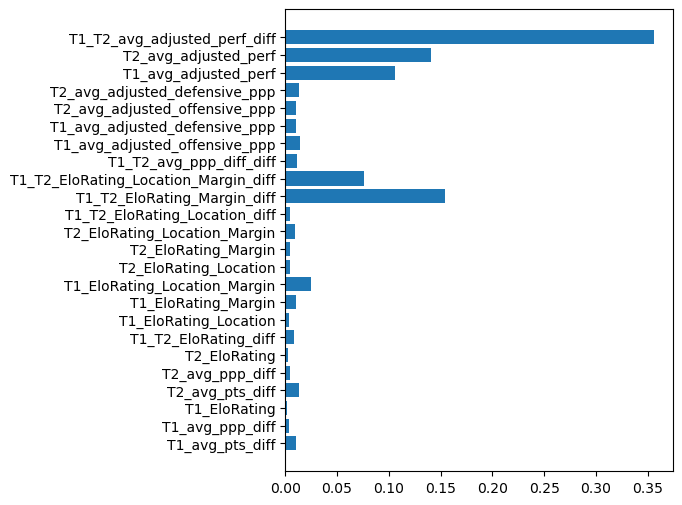

In [56]:
# Feature Importances
importances = gbm_class.feature_importances_
fig, ax = plt.subplots(figsize=(5, 6))
ax.barh(range(len(importances)), importances)
ax.tick_params(axis='y', colors='black', labelsize=10)
ax.set_yticklabels(model_features)
plt.yticks(range(len(importances)), model_features)
plt.show()

In [277]:
# # Create Preds on training data set
# gbm_preds = gbm_class.predict_proba(train_df[model_features])[:, 1]
# print(gbm_preds[0:10])

# # Evaluate model on training data set
# print(log_loss(train_df['T1_Win'], gbm_preds))
# print(brier_score_loss(train_df['T1_Win'], gbm_preds))

### Time-based model training

In [57]:
eval_seasons = [2021, 2022, 2023, 2024]
for ssn_year in eval_seasons:
    print(f'Season: {ssn_year}', end=' ')
    train_data = train_df[train_df['Season'] < ssn_year]
    val_data = train_df[train_df['Season'] == ssn_year]
    
    gbm_class.fit(train_data[model_features], train_data['T1_Win'])
    gbm_preds = gbm_class.predict_proba(val_data[model_features])[:, 1]
    logloss_val = np.round(log_loss(val_data['T1_Win'], gbm_preds),3)
    print(f'Logloss: {logloss_val}', end=' ')
    brier_score_val = np.round(brier_score_loss(val_data['T1_Win'], gbm_preds),3)
    print(f'Brier score: {brier_score_val}')

Season: 2021 Logloss: 0.447 Brier score: 0.146
Season: 2022 Logloss: 0.49 Brier score: 0.164
Season: 2023 Logloss: 0.476 Brier score: 0.158
Season: 2024 Logloss: 0.41 Brier score: 0.134


### Parameter tuning

In [58]:
param_grid = {
        'n_estimators': [80, 100],
        'max_depth': [3,4],
        'max_features': [7, 8, 9],
        'learning_rate': [0.04, 0.05, 0.08]
    }

In [59]:
gbm_class = GradientBoostingClassifier(random_state=0)

estimator = GridSearchCV(gbm_class,
                         param_grid, 
                         scoring='neg_log_loss',
                         n_jobs=-1)

In [60]:
# fit model
estimator.fit(train_df[model_features], 
              train_df['T1_Win'])

GridSearchCV(estimator=GradientBoostingClassifier(random_state=0), n_jobs=-1,
             param_grid={'learning_rate': [0.04, 0.05, 0.08],
                         'max_depth': [3, 4], 'max_features': [7, 8, 9],
                         'n_estimators': [80, 100]},
             scoring='neg_log_loss')

In [61]:
estimator.best_params_

{'learning_rate': 0.04, 'max_depth': 3, 'max_features': 9, 'n_estimators': 100}

In [ ]:
# TODO: Convert parameter tuning CV to time-based loop

CV_SPLITS = 3

eval_seasons = [2021, 2022, 2023, 2024]
for ssn_year in eval_seasons:
    print(f'Season: {ssn_year}:')
    train_data = train_df[train_df['Season'] < ssn_year]
    val_data = train_df[train_df['Season'] == ssn_year]

    inner_cv = TimeSeriesSplit(n_splits=CV_SPLITS)
    grid_search = GridSearchCV(model, param_grid, cv=inner_cv, scoring='neg_log_loss') # or another score
    grid_search.fit(X_train, y_train)

### Logistic Regression

In [62]:
logistic = linear_model.LogisticRegression()

In [63]:
logistic_model_fields = [
    "T1_EloRating_Location"
    , "T2_EloRating_Location"
    , 'T1_avg_adjusted_perf'
    , 'T2_avg_adjusted_perf'
]

In [64]:
eval_seasons = [2021, 2022, 2023, 2024]
for ssn_year in eval_seasons:
    print(f'Season: {ssn_year}', end=' ')
    train_data = train_df[train_df['Season'] < ssn_year]
    val_data = train_df[train_df['Season'] == ssn_year]

    logistic.fit(train_data[logistic_model_fields], train_data['T1_Win'])
    log_preds = logistic.predict_proba(val_data[logistic_model_fields])[:, 1]
    logloss_val = np.round(log_loss(val_data['T1_Win'], log_preds),3)
    print(f'Logloss: {logloss_val}', end=' ')
    brier_score_val = np.round(brier_score_loss(val_data['T1_Win'], log_preds),3)
    print(f'Brier score: {brier_score_val}')

Season: 2021 Logloss: 0.454 Brier score: 0.148
Season: 2022 Logloss: 0.458 Brier score: 0.151
Season: 2023 Logloss: 0.502 Brier score: 0.171
Season: 2024 Logloss: 0.429 Brier score: 0.141


In [65]:
logistic.coef_

array([[ 2.71229144e-03, -2.71229402e-03,  6.72752450e+00,
        -6.72752444e+00]])

### Elo-based prediction

In [66]:
def calculate_expected_score(winner_rating, loser_rating, scaling_factor):
    """Calculates the expected score (probability) of the winner."""
    return 1 / (1 + 10**((loser_rating - winner_rating) / scaling_factor))

In [67]:
eval_seasons = [2021, 2022, 2023, 2024]
for ssn_year in eval_seasons:
    print(f'Season: {ssn_year}', end=' ')
    train_data = train_df[train_df['Season'] < ssn_year]
    val_data = train_df[train_df['Season'] == ssn_year]

    elo_preds = val_data.apply(
        lambda row: calculate_expected_score(row['T1_EloRating'], row['T2_EloRating'], scaling_factor=400),
        axis=1
    )
    logloss_val = np.round(log_loss(val_data['T1_Win'], elo_preds),3)
    print(f'Logloss: {logloss_val}', end=' ')
    brier_score_val = np.round(brier_score_loss(val_data['T1_Win'], elo_preds),3)
    print(f'Brier score: {brier_score_val}')

Season: 2021 Logloss: 0.629 Brier score: 0.219
Season: 2022 Logloss: 0.604 Brier score: 0.208
Season: 2023 Logloss: 0.602 Brier score: 0.207
Season: 2024 Logloss: 0.599 Brier score: 0.206


## Train regression model

In [68]:
from sklearn.ensemble import GradientBoostingRegressor

In [69]:
import scipy

In [70]:
gbm_ps = GradientBoostingRegressor(n_estimators=150, 
                                max_depth=4, 
                                 max_features=5,
                                learning_rate=0.06)

In [71]:
train_df.head()

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,score_diff,T1_Win,T1_num_games,T1_win_pct,T1_avg_pts_scored,T1_avg_opp_pts_scored,T1_avg_PPP,T1_avg_opp_PPP,T1_avg_pts_diff,T1_avg_ppp_diff,T2_num_games,T2_win_pct,T2_avg_pts_scored,T2_avg_opp_pts_scored,T2_avg_PPP,T2_avg_opp_PPP,T2_avg_pts_diff,T2_avg_ppp_diff,T1_EloRating,T1_EloRating_Location,T1_EloRating_Margin,T1_EloRating_Location_Margin,T2_EloRating,T2_EloRating_Location,T2_EloRating_Margin,T2_EloRating_Location_Margin,T1_avg_adjusted_offensive_ppp,T1_avg_adjusted_defensive_ppp,T2_avg_adjusted_offensive_ppp,T2_avg_adjusted_defensive_ppp,T1_T2_EloRating_diff,T1_T2_EloRating_Location_diff,T1_T2_EloRating_Margin_diff,T1_T2_EloRating_Location_Margin_diff,T1_T2_avg_ppp_diff_diff,T1_avg_adjusted_perf,T2_avg_adjusted_perf,T1_T2_avg_adjusted_perf_diff
0,2010,138,3124,69,3201,55,14,1,32,0.718750,72.093750,56.843750,0.996586,0.795086,15.250000,0.201500,33,0.818182,73.454545,60.575758,1.016860,0.838349,12.878788,0.178511,1157.524136,1137.898813,1270.850332,1240.641166,1210.844633,1190.533339,1305.496495,1276.801517,1.110004,0.656291,1.098467,0.775708,-53.320496,-52.634526,-34.646162,-36.160352,0.022989,0.453713,0.322759,0.130954
1,2012,139,3207,61,3201,56,5,1,30,0.733333,60.233333,51.933333,0.870661,0.749468,8.300000,0.121193,33,0.848485,75.484848,62.212121,1.023534,0.843631,13.272727,0.179903,1162.415392,1143.621149,1270.912229,1239.843198,1196.781543,1186.693396,1281.580194,1267.049562,0.981244,0.585259,1.000307,0.757794,-34.366152,-43.072247,-10.667965,-27.206364,-0.058710,0.395985,0.242513,0.153472
2,2014,138,3304,74,3201,55,19,1,31,0.806452,75.612903,63.096774,1.065935,0.887727,12.516129,0.178208,30,0.666667,70.100000,65.033333,0.968559,0.901485,5.066667,0.067074,1228.914624,1203.266472,1382.938841,1343.573724,1122.667875,1112.316550,1175.516525,1158.727811,1.071157,0.676478,1.019216,0.835906,106.246748,90.949922,207.422315,184.845914,0.111134,0.394679,0.183311,0.211368
3,2011,138,3314,82,3201,68,14,1,34,0.764706,77.911765,60.882353,0.991800,0.776715,17.029412,0.215085,32,0.781250,76.125000,64.968750,1.022154,0.870241,11.156250,0.151913,1183.138961,1166.093376,1311.725626,1291.817794,1191.642867,1176.461203,1281.418872,1263.182749,1.119931,0.650989,1.041562,0.756739,-8.503906,-10.367827,30.306753,28.635045,0.063172,0.468942,0.284823,0.184119
4,2013,138,3143,90,3201,76,14,1,31,0.903226,71.580645,56.838710,1.026118,0.817189,14.741935,0.208929,31,0.741935,67.548387,60.645161,0.975174,0.879058,6.903226,0.096116,1251.363449,1225.346122,1371.713145,1338.245579,1149.735160,1138.393066,1197.015501,1180.908531,1.124948,0.695376,1.017116,0.838702,101.628289,86.953056,174.697644,157.337048,0.112813,0.429572,0.178414,0.251158


In [72]:
gbm_ps.fit(train_df[model_features], 
              train_df['score_diff'])

GradientBoostingRegressor(learning_rate=0.06, max_depth=4, max_features=5,
                          n_estimators=150)

/var/folders/z8/cq1dfpbx7zbdmh7y30n1vyyw0000gn/T/ipykernel_1796/3508004879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(model_features)


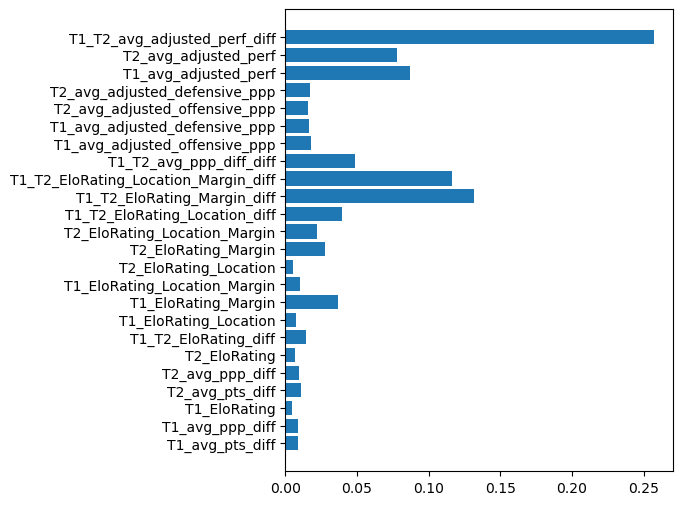

In [73]:
# Feature Importances
importances = gbm_ps.feature_importances_
fig, ax = plt.subplots(figsize=(5, 6))
ax.barh(range(len(importances)), importances)
ax.tick_params(axis='y', colors='black', labelsize=10)
ax.set_yticklabels(model_features)
plt.yticks(range(len(importances)), model_features)
plt.show()

In [74]:
# create preds
ps_preds = gbm_ps.predict(train_df[model_features])
# convert from points diff to probability
gbm_ps_preds = np.array([scipy.stats.norm(0,10.5).cdf(pred) for pred in ps_preds])

In [75]:
# TODO: tune parameters

#### Evaluate model

In [76]:
eval_seasons = [2021, 2022, 2023, 2024]
for ssn_year in eval_seasons:
    print(f'Season: {ssn_year}', end=' ')
    train_data = train_df[train_df['Season'] < ssn_year]
    val_data = train_df[train_df['Season'] == ssn_year]

    gbm_ps.fit(train_data[model_features], train_data['score_diff'])
    # create preds
    ps_preds = gbm_ps.predict(val_data[model_features])
    # convert from points diff to probability
    gbm_ps_preds = np.array([scipy.stats.norm(0,10.5).cdf(pred) for pred in ps_preds])

    logloss_val = np.round(log_loss(val_data['T1_Win'], gbm_ps_preds),3)
    print(f'Logloss: {logloss_val}', end=' ')
    brier_score_val = np.round(brier_score_loss(val_data['T1_Win'], gbm_ps_preds),3)
    print(f'Brier score: {brier_score_val}')

Season: 2021 Logloss: 0.405 Brier score: 0.131
Season: 2022 Logloss: 0.48 Brier score: 0.16
Season: 2023 Logloss: 0.499 Brier score: 0.167
Season: 2024 Logloss: 0.417 Brier score: 0.136


## Ensemble Model

In [77]:
eval_seasons = [2021, 2022, 2023, 2024]
for ssn_year in eval_seasons:
    print(f'Season: {ssn_year}', end=' ')
    train_data = train_df[train_df['Season'] < ssn_year]
    val_data = train_df[train_df['Season'] == ssn_year]

    gbm_class.fit(train_data[model_features], train_data['T1_Win'])
    gbm_preds = gbm_class.predict_proba(val_data[model_features])[:, 1]
    
    gbm_ps.fit(train_data[model_features], train_data['score_diff'])
    # create preds
    ps_preds = gbm_ps.predict(val_data[model_features])
    # convert from points diff to probability
    gbm_ps_preds = np.array([scipy.stats.norm(0,10.5).cdf(pred) for pred in ps_preds])

    logistic.fit(train_data[logistic_model_fields], train_data['T1_Win'])
    log_preds = logistic.predict_proba(val_data[logistic_model_fields])[:, 1]

    ensemble_preds = (gbm_preds + gbm_ps_preds + log_preds) / 3.0
    
    logloss_val = np.round(log_loss(val_data['T1_Win'], ensemble_preds),3)
    print(f'Logloss: {logloss_val}', end=' ')
    brier_score_val = np.round(brier_score_loss(val_data['T1_Win'], ensemble_preds),3)
    print(f'Brier score: {brier_score_val}')

Season: 2021 Logloss: 0.413 Brier score: 0.133
Season: 2022 Logloss: 0.476 Brier score: 0.16
Season: 2023 Logloss: 0.49 Brier score: 0.165
Season: 2024 Logloss: 0.413 Brier score: 0.137


In [80]:
train_df['T2_TeamID'].max()

3465

## 2025 predictions

In [81]:
sample_sub = pd.read_csv("/Users/jeremy/Desktop/nonsense/cbb_modeling/data/SampleSubmissionStage2.csv")
print(sample_sub.shape)

(131407, 2)


In [82]:
sample_sub[['Season', 'T1_TeamID', 'T2_TeamID']] = sample_sub['ID'].str.split('_', expand = True)
sample_sub['T1_TeamID'] = sample_sub['T1_TeamID'].astype(int)
sample_sub['T2_TeamID'] = sample_sub['T2_TeamID'].astype(int)
sample_sub['Season'] = sample_sub['Season'].astype(int)

In [83]:
sample_sub = sample_sub[(sample_sub['T1_TeamID'] >= 3000) & (sample_sub['T1_TeamID'] < 4000) & 
(sample_sub['T2_TeamID'] >= 3000) & (sample_sub['T2_TeamID'] < 4000)]

In [84]:
sample_sub = pd.merge(left=sample_sub, 
                      right=teams[['TeamID', 'TeamName']], 
                      left_on='T1_TeamID', 
                      right_on='TeamID', 
                      how='left')
sample_sub = sample_sub.rename( columns = { 'TeamName' : 'T1_TeamName'})
sample_sub = sample_sub.drop(['TeamID'], axis=1)

print(sample_sub.shape)

(65341, 6)


In [85]:
sample_sub = pd.merge(left=sample_sub, 
                      right=teams[['TeamID', 'TeamName']], 
                      left_on='T2_TeamID', 
                      right_on='TeamID', 
                      how='left')
sample_sub = sample_sub.rename( columns = { 'TeamName' : 'T2_TeamName'})
sample_sub = sample_sub.drop(['TeamID'], axis=1)

print(sample_sub.shape)

(65341, 7)


In [86]:
sample_sub = pd.merge(left=sample_sub, 
                    right=reg_season_feats_T1, 
                    how='left', 
                    on = ['Season', 'T1_TeamID'])

sample_sub = pd.merge(left=sample_sub, 
                    right=reg_season_feats_T2, 
                    how='left', 
                    on = ['Season', 'T2_TeamID'])
print(sample_sub.shape)

(65341, 23)


In [87]:
sample_sub = pd.merge(left=sample_sub, 
                    right=elo_feats_T1, 
                    how='left', 
                    on = ['Season', 'T1_TeamID'])

sample_sub = pd.merge(left=sample_sub, 
                    right=elo_feats_T2, 
                    how='left', 
                    on = ['Season', 'T2_TeamID'])
print(sample_sub.shape)

(65341, 31)


In [88]:
# Join in adjusted_metrics_df
sample_sub = pd.merge(left=sample_sub, 
                    right=adjusted_metrics_df_T1[['Season', 'T1_TeamID','T1_avg_adjusted_offensive_ppp', 'T1_avg_adjusted_defensive_ppp']], 
                    how='left', 
                    on = ['Season', 'T1_TeamID'])

sample_sub = pd.merge(left=sample_sub, 
                    right=adjusted_metrics_df_T2[['Season', 'T2_TeamID','T2_avg_adjusted_offensive_ppp', 'T2_avg_adjusted_defensive_ppp']], 
                    how='left', 
                    on = ['Season', 'T2_TeamID'])

print(sample_sub.shape)

(65341, 35)


In [89]:
# Create T1-T2 interaction features
sample_sub['T1_T2_EloRating_diff'] = sample_sub['T1_EloRating'] - sample_sub['T2_EloRating']

sample_sub['T1_T2_EloRating_Location_diff'] = sample_sub['T1_EloRating_Location'] - sample_sub['T2_EloRating_Location']
sample_sub['T1_T2_EloRating_Margin_diff'] = sample_sub['T1_EloRating_Margin'] - sample_sub['T2_EloRating_Margin']
sample_sub['T1_T2_EloRating_Location_Margin_diff'] = sample_sub['T1_EloRating_Location_Margin'] - sample_sub['T2_EloRating_Location_Margin']

sample_sub['T1_T2_avg_ppp_diff_diff'] = sample_sub['T1_avg_ppp_diff'] - sample_sub['T2_avg_ppp_diff']

sample_sub['T1_avg_adjusted_perf'] = sample_sub['T1_avg_adjusted_offensive_ppp'] - sample_sub['T1_avg_adjusted_defensive_ppp']
sample_sub['T2_avg_adjusted_perf'] = sample_sub['T2_avg_adjusted_offensive_ppp'] - sample_sub['T2_avg_adjusted_defensive_ppp']

sample_sub['T1_T2_avg_adjusted_perf_diff'] = sample_sub['T1_avg_adjusted_perf'] - sample_sub['T2_avg_adjusted_perf']

In [90]:
# Create predictions
preds = gbm_class.predict_proba(sample_sub[model_features])[:, 1]
sample_sub['gbm_pred'] = np.round(preds,3)

In [91]:
ps_preds = gbm_ps.predict(sample_sub[model_features])
# convert from points diff to probability
gbm_ps_preds = np.array([scipy.stats.norm(0,10.5).cdf(pred) for pred in ps_preds])

In [92]:
sample_sub['ps_preds'] = np.round(ps_preds,1)
sample_sub['gbm_ps_preds'] = np.round(gbm_ps_preds,3)

In [93]:
log_preds = logistic.predict_proba(sample_sub[logistic_model_fields])[:, 1]

In [94]:
sample_sub['log_preds'] = np.round(log_preds,3)

In [95]:
# Ensemble predictions together
sample_sub['Pred'] = np.round((sample_sub['gbm_pred'] + sample_sub['gbm_ps_preds'] + sample_sub['log_preds']) / 3.0,3)

In [113]:
# Apply gambling strategy

TEAM_PICK = 3376
sample_sub['Pred'] = np.where(sample_sub['T1_TeamID']==TEAM_PICK, 0.999, sample_sub['Pred'])
sample_sub['Pred'] = np.where(sample_sub['T2_TeamID']==TEAM_PICK, 0.001, sample_sub['Pred'])

In [114]:
sample_sub.head()

,ID,Pred,Season,T1_TeamID,T2_TeamID,T1_TeamName,T2_TeamName,T1_num_games,T1_win_pct,T1_avg_pts_scored,T1_avg_opp_pts_scored,T1_avg_PPP,T1_avg_opp_PPP,T1_avg_pts_diff,T1_avg_ppp_diff,T2_num_games,T2_win_pct,T2_avg_pts_scored,T2_avg_opp_pts_scored,T2_avg_PPP,T2_avg_opp_PPP,T2_avg_pts_diff,T2_avg_ppp_diff,T1_EloRating,T1_EloRating_Location,T1_EloRating_Margin,T1_EloRating_Location_Margin,T2_EloRating,T2_EloRating_Location,T2_EloRating_Margin,T2_EloRating_Location_Margin,T1_avg_adjusted_offensive_ppp,T1_avg_adjusted_defensive_ppp,T2_avg_adjusted_offensive_ppp,T2_avg_adjusted_defensive_ppp,T1_T2_EloRating_diff,T1_T2_EloRating_Location_diff,T1_T2_EloRating_Margin_diff,T1_T2_EloRating_Location_Margin_diff,T1_T2_avg_ppp_diff_diff,T1_avg_adjusted_perf,T2_avg_adjusted_perf,T1_T2_avg_adjusted_perf_diff,gbm_pred,ps_preds,gbm_ps_preds,log_preds
0,2025_3101_3102,0.600,2025,3101,3102,Abilene Chr,Air Force,29,0.586207,68.413793,64.103448,0.940681,0.884514,4.310345,0.056167,30,0.533333,65.433333,63.900000,0.928607,0.909036,1.533333,0.019571,1030.725454,1032.053173,1029.521962,1037.457509,999.736616,1000.738300,1005.578125,1002.467732,0.985344,0.857596,0.946070,0.833533,30.988838,31.314872,23.943837,34.989776,0.036596,0.127748,0.112538,0.015210,0.702,1.3,0.551,0.547
1,2025_3101_3103,0.859,2025,3101,3103,Abilene Chr,Akron,29,0.586207,68.413793,64.103448,0.940681,0.884514,4.310345,0.056167,29,0.275862,61.448276,69.137931,0.872782,0.982991,-7.689655,-0.110209,1030.725454,1032.053173,1029.521962,1037.457509,843.899439,859.497984,762.659235,782.310576,0.985344,0.857596,0.840322,0.841162,186.826015,172.555189,266.862728,255.146932,0.166376,0.127748,-0.000839,0.128587,0.892,13.1,0.894,0.791
2,2025_3101_3104,0.020,2025,3101,3104,Abilene Chr,Alabama,29,0.586207,68.413793,64.103448,0.940681,0.884514,4.310345,0.056167,31,0.741935,78.354839,62.709677,1.047530,0.838913,15.645161,0.208616,1030.725454,1032.053173,1029.521962,1037.457509,1153.494255,1136.511615,1295.143170,1270.099089,0.985344,0.857596,1.185767,0.622795,-122.768801,-104.458442,-265.621208,-232.641580,-0.152450,0.127748,0.562972,-0.435224,0.014,-25.7,0.007,0.039
3,2025_3101_3105,0.659,2025,3101,3105,Abilene Chr,Alabama A&M,29,0.586207,68.413793,64.103448,0.940681,0.884514,4.310345,0.056167,30,0.666667,64.300000,61.100000,0.897373,0.850849,3.200000,0.046524,1030.725454,1032.053173,1029.521962,1037.457509,1044.737383,1051.964099,1013.835566,1030.598547,0.985344,0.857596,0.856322,0.827553,-14.011929,-19.910926,15.686397,6.858962,0.009643,0.127748,0.028769,0.098979,0.651,4.8,0.677,0.648
4,2025_3101_3106,0.983,2025,3101,3106,Abilene Chr,Alabama St,29,0.586207,68.413793,64.103448,0.940681,0.884514,4.310345,0.056167,28,0.142857,48.035714,71.678571,0.675459,0.999035,-23.642857,-0.323576,1030.725454,1032.053173,1029.521962,1037.457509,774.059067,801.561814,620.764606,663.693075,0.985344,0.857596,0.692269,0.962411,256.666387,230.491359,408.757356,373.764434,0.379743,0.127748,-0.270142,0.397890,0.987,31.9,0.999,0.964


#### Prediction aggregation

In [115]:
orig_preds = sample_sub[['Pred', 'T1_TeamID', 'T2_TeamID']]
flipped_preds = sample_sub[['Pred', 'T1_TeamID', 'T2_TeamID']]
flipped_preds.columns = ['Pred', 'T2_TeamID', 'T1_TeamID']
flipped_preds.loc[:,'Pred'] = 1.0 - flipped_preds['Pred']

In [116]:
full_preds = pd.concat([orig_preds, flipped_preds]).reset_index(drop=True)
full_preds.shape

(130682, 3)

In [117]:
pred_avgs = full_preds.groupby(['T1_TeamID']).agg(
    T1_avg_pred_pct=('Pred','mean'),
    num_games=('Pred','count')
).reset_index()

In [118]:
pred_avgs = pd.merge(left=pred_avgs, 
                     right=teams, 
                     left_on='T1_TeamID', 
                     right_on='TeamID', 
                     how='left')

In [119]:
pred_avgs = pd.merge(left=pred_avgs, 
                     right=elo_feats_T1[elo_feats_T1['Season']==2025], 
                     how='left',
                     on = 'T1_TeamID')

In [120]:
pred_avgs.sort_values('T1_avg_pred_pct', ascending=False).head(25)[['TeamID', 'TeamName', 'T1_avg_pred_pct', 'T1_EloRating']]

,TeamID,TeamName,T1_avg_pred_pct,T1_EloRating
262,3376,South Carolina,0.999000,1321.248108
55,3163,Connecticut,0.981839,1305.820935
285,3400,Texas,0.970219,1320.101780
302,3417,UCLA,0.967427,1324.436984
211,3323,Notre Dame,0.959834,1240.084261
310,3425,USC,0.954717,1300.602513
73,3181,Duke,0.948111,1252.050880
280,3395,TCU,0.947848,1302.953408
333,3452,West Virginia,0.933285,1204.492828
282,3397,Tennessee,0.925615,1139.834280


#### Look at first round games

In [104]:
# first_round_games = [
#     '2025_1285_1458'  # Mont-Wisc
#     ,'2025_1106_1120'  # AlabamaSt-Auburn
#     ,'2025_1208_1211'  # Georgia-Gonz
#     ,'2025_1279_1314'  # Miss-UNC
#     ,'2025_1179_1281'  # Drake-Mizzou
#     ,'2025_1401_1463'  # TXAM-Yale
#     ,'2025_1161_1272'  # ColSt-Memphis
#     ,'2025_1251_1332'  # Liberty-Oregon
#     ,'2025_1103_1112'  # Akron-AZ
#     ,'2025_1155_1270'  # Clem-Mcneese
#     ,'2025_1181_1291'  # Duke-MtStM
# ]

In [103]:
# fields_to_view = ['T1_TeamName', 'T2_TeamName', 'Pred', 'gbm_pred', 'log_preds', 'gbm_ps_preds']

# sample_sub[sample_sub['ID'].isin(first_round_games)].sort_values('Pred')[fields_to_view]